In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)


df = pd.read_csv('data_.csv') 


df.head()

,client_id,app_date,education,sex,age,car,car_type,decline_app_cnt,good_work,score_bki,bki_request_cnt,region_rating,home_address,work_address,income,sna,first_time,foreign_passport,default
0,25905,01FEB2014,SCH,M,62,Y,Y,0,0,-2.008753,1,50,1,2,18000,4,1,N,0
1,63161,12MAR2014,SCH,F,59,N,N,0,0,-1.532276,3,50,2,3,19000,4,1,N,0
2,25887,01FEB2014,SCH,M,25,Y,N,2,0,-1.408142,1,80,1,2,30000,1,4,Y,0
3,16222,23JAN2014,SCH,F,53,N,N,0,0,-2.057471,2,50,2,3,10000,1,3,N,0
4,101655,18APR2014,GRD,M,48,N,N,0,1,-1.244723,1,60,2,3,30000,1,4,Y,0


In [ ]:
print("Исходная информация о данных")
df.info()

print("\nПропуски до обработки")
display(df.isnull().sum()[df.isnull().sum() > 0])


df['education'] = df['education'].fillna('Unknown')

print("\nПропуски после обработки в education:", df['education'].isnull().sum())

=== Исходная информация о данных ===
<class 'pandas.DataFrame'>
RangeIndex: 73799 entries, 0 to 73798
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         73799 non-null  int64  
 1   app_date          73799 non-null  str    
 2   education         73799 non-null  str    
 3   sex               73799 non-null  str    
 4   age               73799 non-null  int64  
 5   car               73799 non-null  str    
 6   car_type          73799 non-null  str    
 7   decline_app_cnt   73799 non-null  int64  
 8   good_work         73799 non-null  int64  
 9   score_bki         73799 non-null  float64
 10  bki_request_cnt   73799 non-null  int64  
 11  region_rating     73799 non-null  int64  
 12  home_address      73799 non-null  int64  
 13  work_address      73799 non-null  int64  
 14  income            73799 non-null  int64  
 15  sna               73799 non-null  int64  
 16  first_time    

Series([], dtype: int64)


Пропуски после обработки в education: 0


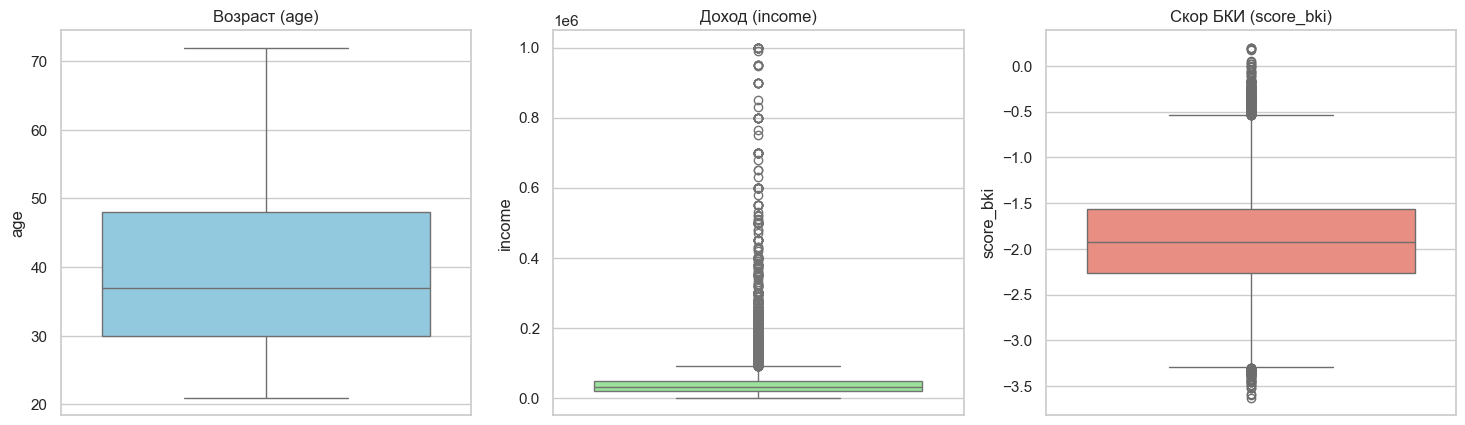

Удалено строк с аномальным доходом: 4695


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df['age'], ax=axes[0], color='skyblue').set_title('Возраст (age)')
sns.boxplot(y=df['income'], ax=axes[1], color='lightgreen').set_title('Доход (income)')
sns.boxplot(y=df['score_bki'], ax=axes[2], color='salmon').set_title('Скор БКИ (score_bki)')
plt.show()


q1 = df['income'].quantile(0.25)
q3 = df['income'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_clean = df[(df['income'] >= lower_bound) & (df['income'] <= upper_bound)].copy()

print(f"Удалено строк с аномальным доходом: {len(df) - len(df_clean)}")



Корреляционная матрица:


,age,decline_app_cnt,bki_request_cnt,income,score_bki,region_rating
age,1.000000,-0.124724,0.046461,-0.128239,-0.114926,-0.093528
decline_app_cnt,-0.124724,1.000000,0.108479,0.004091,0.202254,-0.028425
bki_request_cnt,0.046461,0.108479,1.000000,0.064781,0.124034,-0.015757
income,-0.128239,0.004091,0.064781,1.000000,0.021086,0.296398
score_bki,-0.114926,0.202254,0.124034,0.021086,1.000000,0.015203
region_rating,-0.093528,-0.028425,-0.015757,0.296398,0.015203,1.000000


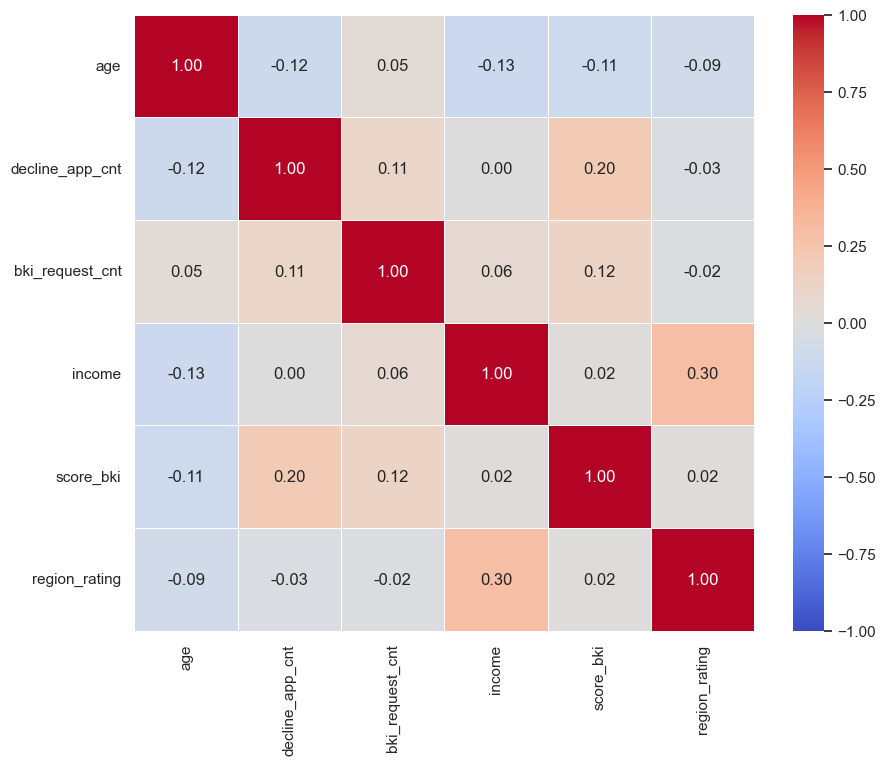

In [ ]:

num_cols = ['age', 'decline_app_cnt', 'bki_request_cnt', 'income', 'score_bki', 'region_rating']

plt.figure(figsize=(10, 8))

corr_matrix = df_clean[num_cols].corr(method='spearman') 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
print("\nКорреляционная матрица:")

display(corr_matrix)
plt.show()

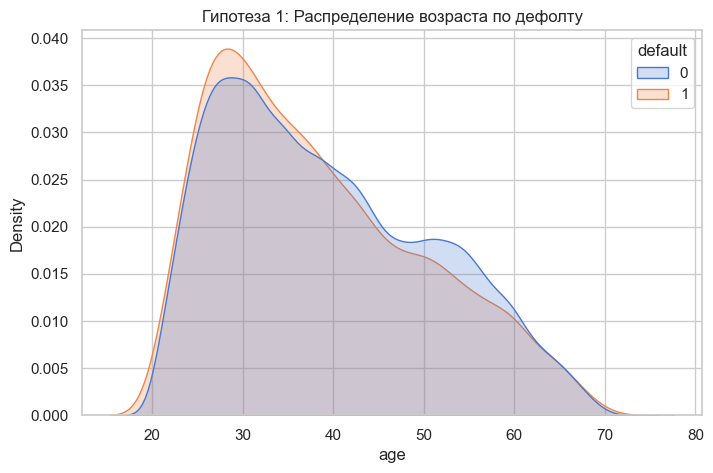

Средний возраст:


default
0    39.3
1    38.4
Name: age, dtype: float64

In [ ]:

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_clean, x='age', hue='default', common_norm=False, fill=True)
plt.title('Гипотеза 1: Распределение возраста по дефолту')
plt.show()

print("Средний возраст:")
display(df_clean.groupby('default')['age'].mean().round(1))

/var/folders/9l/grk_769s4j3_gnpcm9_68y740000gn/T/ipykernel_20960/2144420106.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_default.index, y=edu_default.values, ax=axes[1], palette='viridis')


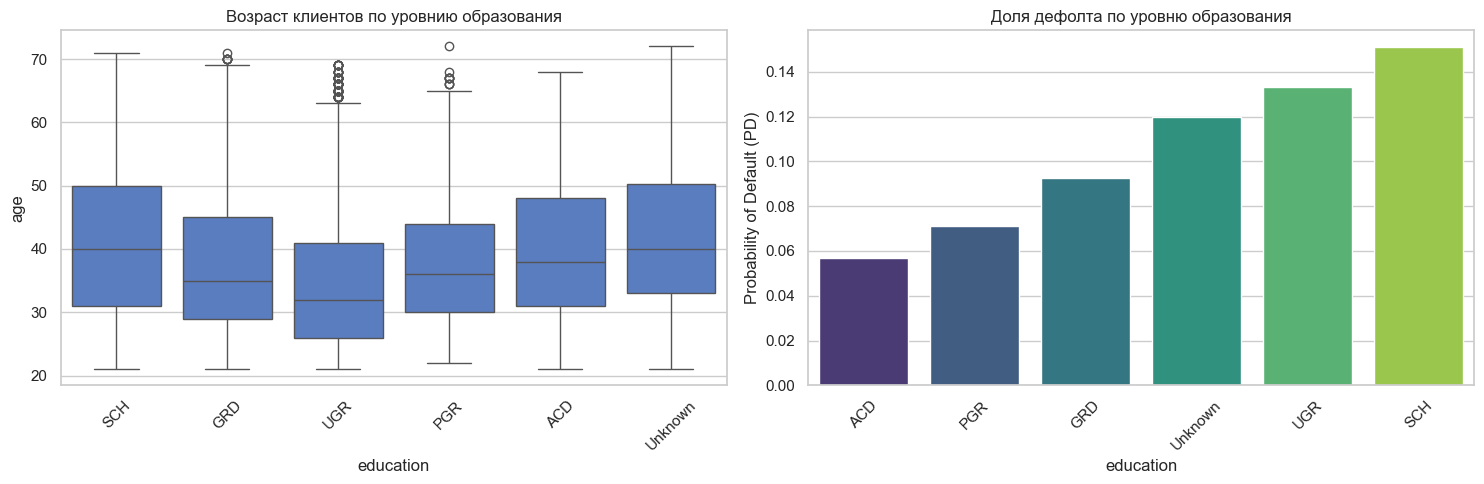

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.boxplot(data=df_clean, x='education', y='age', ax=axes[0])
axes[0].set_title('Возраст клиентов по уровнию образования')
axes[0].tick_params(axis='x', rotation=45)


edu_default = df_clean.groupby('education')['default'].mean().sort_values()
sns.barplot(x=edu_default.index, y=edu_default.values, ax=axes[1], palette='viridis')
axes[1].set_title('Доля дефолта по уровню образования')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Probability of Default (PD)')

plt.tight_layout()
plt.show()

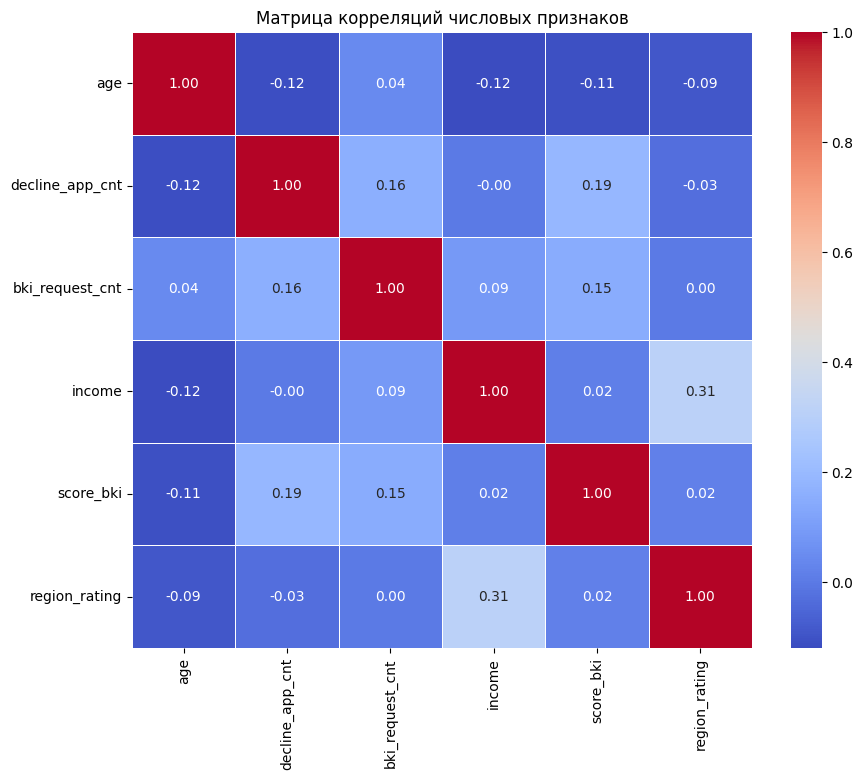

In [ ]:

num_cols = ['age', 'decline_app_cnt', 'bki_request_cnt', 'income', 'score_bki', 'region_rating']

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матрица корреляций числовых признаков')
plt.show()

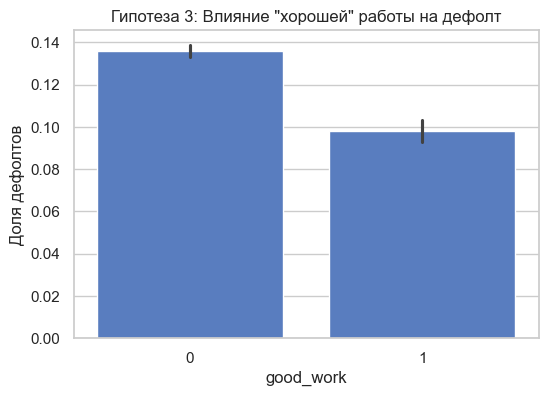

Доля дефолта (в %):


good_work
0    13.60
1     9.81
Name: default, dtype: float64

In [ ]:

plt.figure(figsize=(6, 4))
sns.barplot(x='good_work', y='default', data=df_clean)
plt.title('Гипотеза 3: Влияние "хорошей" работы на дефолт')
plt.ylabel('Доля дефолтов')
plt.show()

print("Доля дефолта (в %):")
display((df_clean.groupby('good_work')['default'].mean() * 100).round(2))

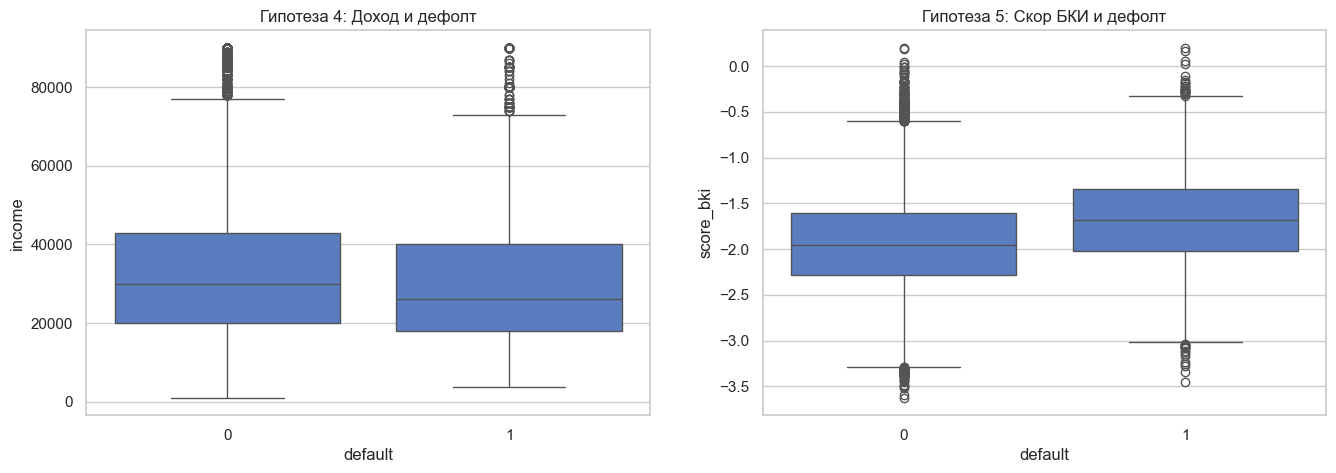

Медианный доход:


default
0    30000.0
1    26000.0
Name: income, dtype: float64


Средний скор БКИ:


default
0   -1.934793
1   -1.677196
Name: score_bki, dtype: float64

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


sns.boxplot(x='default', y='income', data=df_clean, ax=axes[0])
axes[0].set_title('Гипотеза 4: Доход и дефолт')


sns.boxplot(x='default', y='score_bki', data=df_clean, ax=axes[1])
axes[1].set_title('Гипотеза 5: Скор БКИ и дефолт')

plt.show()

print("Медианный доход:")
display(df_clean.groupby('default')['income'].median())
print("\nСредний скор БКИ:")
display(df_clean.groupby('default')['score_bki'].mean())

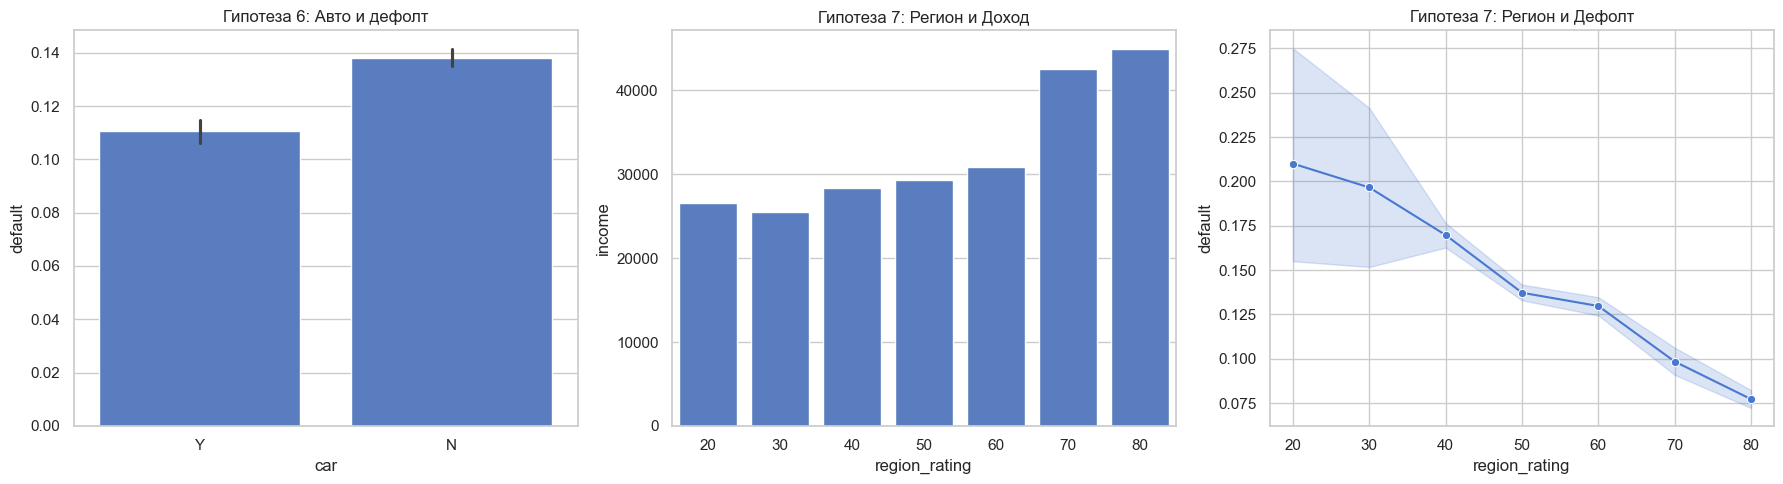

In [27]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.barplot(x='car', y='default', data=df_clean, ax=axes[0])
axes[0].set_title('Гипотеза 6: Авто и дефолт')


sns.barplot(x='region_rating', y='income', data=df_clean, ax=axes[1], errorbar=None)
axes[1].set_title('Гипотеза 7: Регион и Доход')


sns.lineplot(x='region_rating', y='default', data=df_clean, marker='o', ax=axes[2])
axes[2].set_title('Гипотеза 7: Регион и Дефолт')

plt.tight_layout()
plt.show()